# Teste 1: Escolha de threshold da separação semântica

Esse notebook foi utilizado para testar qual o melhor threshold semântico aceito pelos chunks, ou seja, com thresholds maiores, maior vai ser a aceitação de contextos "parecidos", acarretando em maiores chunks.

A ideia é entender quanto melhor vai ser isso pro prompt, para isso temos algumas plots para entender qual o melhor caminho a seguir, e algumas visualizações de chunks.

## 1.1 Instalar as Dependências

In [1]:
!pip install -q langchain langchain-community langchain-experimental
!pip install -q langchain-huggingface sentence-transformers
!pip install -q pymupdf pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.1/210.1 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 76.4 MB/s eta 0:00:00


In [2]:
# faz o download do livro pelo notebook python do Colab
!wget https://domainpublic.wordpress.com/wp-content/uploads/2022/10/jk_couto_2ed.pdf

--2026-05-08 02:35:11--  https://domainpublic.wordpress.com/wp-content/uploads/2022/10/jk_couto_2ed.pdf
Resolving domainpublic.wordpress.com (domainpublic.wordpress.com)... 192.0.78.12, 192.0.78.13
Connecting to domainpublic.wordpress.com (domainpublic.wordpress.com)|192.0.78.12|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16321321 (16M) [application/pdf]
Saving to: ‘jk_couto_2ed.pdf’

jk_couto_2ed.pdf    100%[===================>]  15.56M  --.-KB/s    in 0.04s   

2026-05-08 02:35:11 (421 MB/s) - ‘jk_couto_2ed.pdf’ saved [16321321/16321321]



In [3]:
from langchain_community.document_loaders import PyMuPDFLoader

arquivo = 'jk_couto_2ed.pdf'
loader = PyMuPDFLoader(f"/content/{arquivo}")
all_pages = loader.load()


print(f"Total de páginas carregadas: {len(all_pages)}")

Total de páginas carregadas: 473


In [4]:
from langchain_community.document_loaders import PyMuPDFLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_experimental.text_splitter import SemanticChunker
import pandas as pd
import matplotlib.pyplot as plt
import re
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f" Using device: {device}")

 Using device: cuda


In [5]:
arquivo = 'jk_couto_2ed.pdf'
loader = PyMuPDFLoader(f"/content/{arquivo}")
all_pages = loader.load()


print(f"Total de páginas carregadas: {len(all_pages)}")

Total de páginas carregadas: 473


In [6]:
embeddings_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    model_kwargs={"device": device}
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

## 1.2 Testes de thresholds (Porcentagem de aceitação para os chunks)

Para testar os chunks, eu decidi começar em 50% para tentar chegar no maior nível de rigorosidade do chunking e fui até o 100% para tentar chegar no chunking que tentar achar o máximo de contexto e conectar (consequentemente, diminuindo a quantidade de chunks).

In [7]:
thresholds = [50, 60, 70, 80, 85, 90, 95, 100]
results = []

for threshold in thresholds:
    print(f"\n{'='*60}")
    print(f"A testar limite: {threshold}%")

    text_splitter = SemanticChunker(
        embeddings=embeddings_model,
        breakpoint_threshold_type="percentile",
        breakpoint_threshold_amount=threshold
    )

    chunks = text_splitter.split_documents(all_pages)

    chunk_sizes = [len(c.page_content) for c in chunks]

    results.append({
        'threshold': threshold,
        'num_chunks': len(chunks),
        'avg_size': sum(chunk_sizes) / len(chunks),
        'min_size': min(chunk_sizes),
        'max_size': max(chunk_sizes),
        'chunks': chunks
    })

    print(f"Chunks: {len(chunks)} | Média: {results[-1]['avg_size']:.0f} | Mín: {min(chunk_sizes)} | Máx: {max(chunk_sizes)}")


A testar limite: 50%
Chunks: 4046 | Média: 179 | Mín: 0 | Máx: 1876

A testar limite: 60%
Chunks: 3406 | Média: 213 | Mín: 0 | Máx: 1876

A testar limite: 70%
Chunks: 2734 | Média: 266 | Mín: 0 | Máx: 1876

A testar limite: 80%
Chunks: 2024 | Média: 360 | Mín: 0 | Máx: 1908

A testar limite: 85%
Chunks: 1705 | Média: 427 | Mín: 0 | Máx: 2118

A testar limite: 90%
Chunks: 1354 | Média: 538 | Mín: 0 | Máx: 2118

A testar limite: 95%
Chunks: 1022 | Média: 713 | Mín: 0 | Máx: 2118

A testar limite: 100%
Chunks: 473 | Média: 1543 | Mín: 0 | Máx: 2496


Minha opinião: Os que mais me chamaram atenção foram o 70, 85 e 90, mostrando uma quantidade justa de chunks (pelo tamanho do documento) e uma quantidade de caracteres razoável, sinto que a SLM entende chunks com contextos menores.

### Plot dos dados


📊 Resultados
 threshold  num_chunks    avg_size  min_size  max_size
        50        4046  179.456253         0      1876
        60        3406  213.364651         0      1876
        70        2734  266.054133         0      1876
        80        2024  359.734190         0      1908
        85        1705  427.226393         0      2118
        90        1354  538.236337         0      2118
        95        1022  713.409002         0      2118
       100         473 1542.606765         0      2496


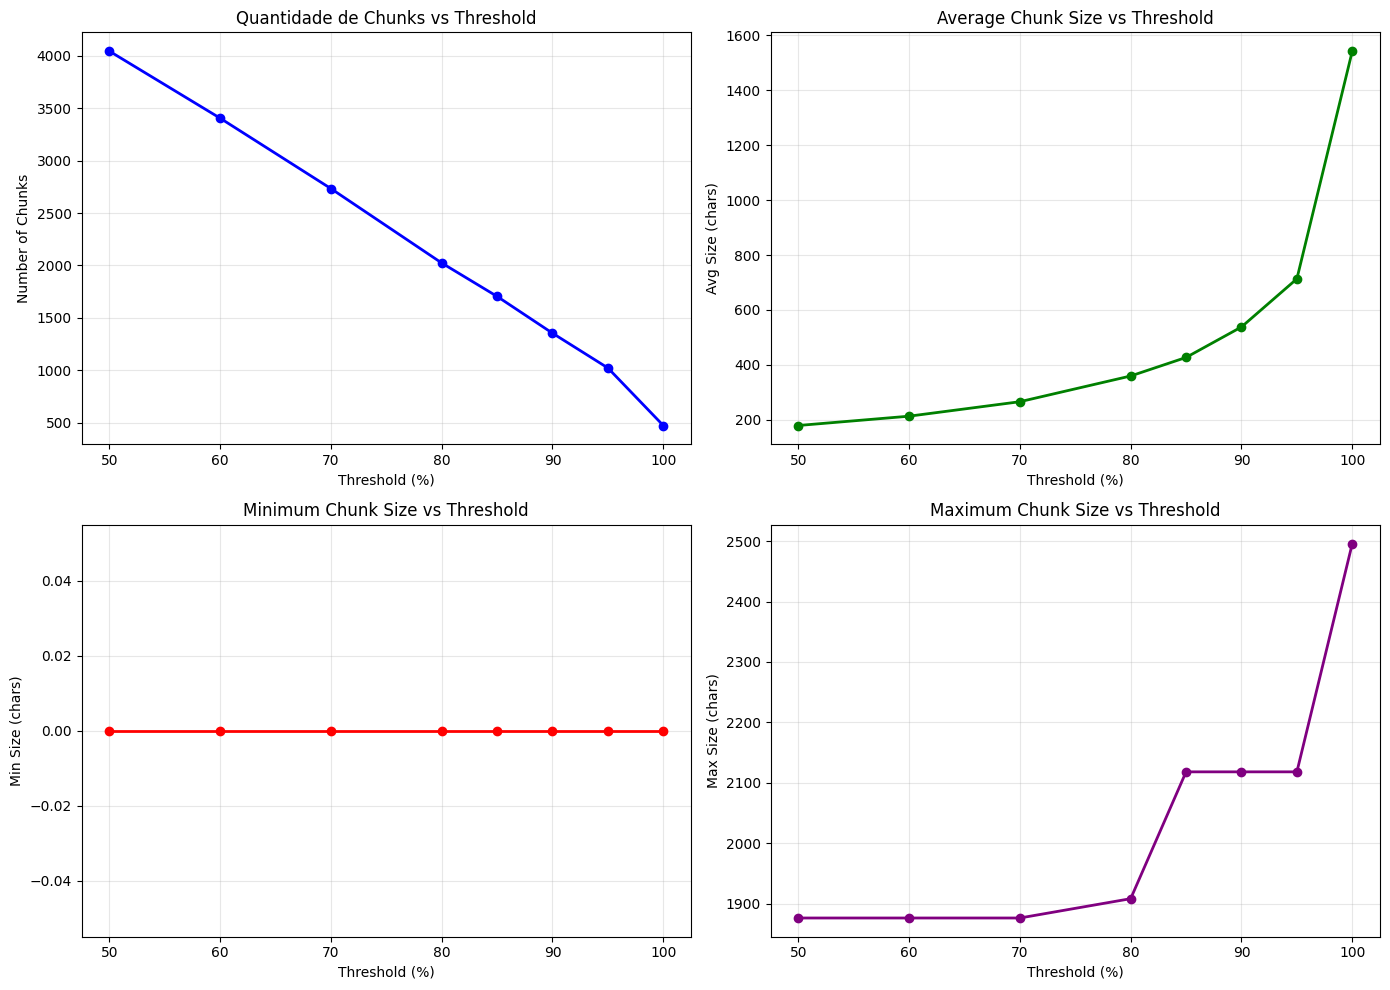

In [8]:
df = pd.DataFrame([{k: v for k, v in r.items() if k != 'chunks'} for r in results])
print("\n📊 Resultados")
print(df.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(df['threshold'], df['num_chunks'], marker='o', linewidth=2, color='blue')
axes[0, 0].set_title('Quantidade de Chunks vs Threshold', fontsize=12)
axes[0, 0].set_xlabel('Threshold (%)')
axes[0, 0].set_ylabel('Number of Chunks')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(df['threshold'], df['avg_size'], marker='o', linewidth=2, color='green')
axes[0, 1].set_title('Average Chunk Size vs Threshold', fontsize=12)
axes[0, 1].set_xlabel('Threshold (%)')
axes[0, 1].set_ylabel('Avg Size (chars)')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(df['threshold'], df['min_size'], marker='o', linewidth=2, color='red')
axes[1, 0].set_title('Minimum Chunk Size vs Threshold', fontsize=12)
axes[1, 0].set_xlabel('Threshold (%)')
axes[1, 0].set_ylabel('Min Size (chars)')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(df['threshold'], df['max_size'], marker='o', linewidth=2, color='purple')
axes[1, 1].set_title('Maximum Chunk Size vs Threshold', fontsize=12)
axes[1, 1].set_xlabel('Threshold (%)')
axes[1, 1].set_ylabel('Max Size (chars)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

A partir disso, vou analisar o conteúdo presente em alguns chunks, os que eu mais gostei

In [9]:
# Análise específica de cada chunk
for result in results:
    if result['threshold'] in [70, 85, 90]:
        threshold = result['threshold']
        chunks = result['chunks']
        chunk_sizes = [len(c.page_content) for c in chunks]

        print(f"\n{'='*80}")
        print(f"THRESHOLD: {threshold}%")
        print(f"{'='*80}")

        print(f"\n--- PRIMEIRO CHUNK ---")
        print(f"Size: {len(chunks[0].page_content)} chars")
        print(chunks[0].page_content[:400] + "...")

        min_idx = chunk_sizes.index(min(chunk_sizes))
        print(f"\n--- MENOR CHUNK (index {min_idx}) ---")
        print(f"Size: {len(chunks[min_idx].page_content)} chars")
        print(chunks[min_idx].page_content)

        max_idx = chunk_sizes.index(max(chunk_sizes))
        print(f"\n--- MAIOR CHUNK (index {max_idx}) ---")
        print(f"Size: {len(chunks[max_idx].page_content)} chars")
        print(chunks[max_idx].page_content[:400] + "...")


THRESHOLD: 70%

--- PRIMEIRO CHUNK ---
Size: 37 chars
Ronaldo Costa Couto
JK
edições
câmara...

--- MENOR CHUNK (index 1) ---
Size: 0 chars


--- MAIOR CHUNK (index 16) ---
Size: 1876 chars
Capítulo 6������������������������������������������������������������������������������������������������������71
Deputado federal Juscelino Kubitschek
Capítulo 7 ������������������������������������������������������������������������������������������������������77
Volta à medicina
Capítulo 8�����������������������������������������������������������������������������������������������������...

THRESHOLD: 85%

--- PRIMEIRO CHUNK ---
Size: 37 chars
Ronaldo Costa Couto
JK
edições
câmara...

--- MENOR CHUNK (index 1) ---
Size: 0 chars


--- MAIOR CHUNK (index 1373) ---
Size: 2118 chars
424 • JK
prevalecer somente este na forma da lei e a fim de determinar as dis­
posições de sua última vontade para valer após seu falecimento pelo 
que compareceu a este cartório e à minha presença para ditar est

Achei meio bizarro esse chunk maior no 70% e 85% ser um monte de chars indiferentes iniciais, porém acredito que fazer uma limpa ajudaria...

### Conclusões finais

Acredito que o que mais me satisfez foi o threshold de 85% por ser uma separação não tão rigorosa e manter uma quant. de caracteres interessante. Gostei do números de chunks também.